In [1]:
# Cell 1: Setting up the python packages 
import pandas as pd
import voltaiq_studio as vs

SOC_series = (100,95,90,80,70,60,50,40,30,20,10,5,0)
current = 42.5

# 1. Get the test records currently loaded or accessible
trs = vs.get_test_records()

# 2. Filter for both target test records (update name fragments)
def filter_test_record_by_name(name):
    return [t for t in trs if name.lower() in t.name.lower()]


In [2]:
trs = vs.get_test_records()

def filter_test_record_by_name(name_fragment):
    return [t for t in trs if name_fragment.lower() in t.name.lower()]

test_names = [
             'CV_0010_CS2D2520_Pr_FastGITT_45C',
             'CV_0010_CS2D8533_Pr_FastGITT_45C'
             ]
filtered_trs = []
for name in test_names:
    filtered_trs.extend(filter_test_record_by_name(name))

In [3]:
print(len(filtered_trs))
for tr in filtered_trs:
    print(tr.name)

2
CV_0010_CS2D2520_Pr_FastGITT_45C
CV_0010_CS2D8533_Pr_FastGITT_45C


In [4]:
for tr in filtered_trs:
    reader = tr.make_time_series_reader()
    reader.add_trace_keys('h_cycle','h_step_index')
    df = reader.read_pandas()

    combos = df[['h_cycle','h_step_index']].drop_duplicates()
    print(tr.name)
    print(combos.sort_values(['h_cycle','h_step_index']).tail(50))

CV_0010_CS2D2520_Pr_FastGITT_45C
        h_cycle  h_step_index
401673      2.0          40.0
426875      2.0          41.0
428375      2.0          42.0
453577      2.0          43.0
454328      2.0          44.0
479534      2.0          45.0
480885      2.0          46.0
506087      2.0          47.0
507289      3.0          47.0
508491      4.0          47.0
509693      4.0          49.0
510444      4.0          50.0
535646      4.0          51.0
536397      4.0          52.0
561599      4.0          53.0
563098      4.0          54.0
588300      4.0          55.0
590547      4.0          56.0
615749      4.0          57.0
617996      4.0          58.0
643198      4.0          59.0
646942      4.0          60.0
657744      4.0          61.0
661488      4.0          62.0
672290      4.0          63.0
679775      4.0          64.0
690577      4.0          65.0
698062      4.0          66.0
708864      4.0          67.0
716349      4.0          68.0
727151      4.0          69.0
734636 

In [6]:
import pandas as pd
import numpy as np

def calculate_gitt_hysteresis(filtered_trs):

    discharge_map = {
        (4,50):99, (4,52):98, (4,54):96, (4,56):93, (4,58):90,
        (4,60):85, (4,62):80, (4,64):70, (4,66):60, (4,68):50,
        (4,70):40, (4,72):30, (4,74):20, (4,76):15, (4,78):10,
        (4,80):7,  (4,82):4,  (4,84):2,  (4,86):1,  (4,88):0
    }

    charge_map = {
        (2,8):1,   (2,10):2,  (2,12):4,  (2,14):7,  (2,16):10,
        (2,18):15, (2,20):20, (2,22):30, (2,24):40, (2,26):50,
        (2,28):60, (2,30):70, (2,32):80, (2,34):85, (2,36):90,
        (2,38):93, (2,40):96, (2,42):98, (2,44):99,(2,46):100
    }

    all_results = []

    for tr in filtered_trs:

        print(f"\n🔍 Processing test: {tr.name}")

        try:
            reader = tr.make_time_series_reader()
            reader.add_trace_keys(
                'aux_neware_xls_voltage_volt_0',
                'h_cycle',
                'h_step_index'
            )
            df = reader.read_pandas()
        except ValueError as e:
            print(f"❌ Skipping {tr.name} due to error:\n{e}")
            continue

        df_sorted = df.sort_values(['h_cycle', 'h_step_index']).reset_index(drop=True)

        # ── Build voltage lookup dicts ────────────────────────────────────────
        charge_voltages = {}
        for (cycle, step), soc in charge_map.items():
            step_data = df_sorted[
                (df_sorted['h_cycle'] == cycle) &
                (df_sorted['h_step_index'] == step)
            ]
            if not step_data.empty:
                charge_voltages[soc] = step_data.iloc[-1]['aux_neware_xls_voltage_volt_0']

        discharge_voltages = {}
        for (cycle, step), soc in discharge_map.items():
            step_data = df_sorted[
                (df_sorted['h_cycle'] == cycle) &
                (df_sorted['h_step_index'] == step)
            ]
            if not step_data.empty:
                discharge_voltages[soc] = step_data.iloc[-1]['aux_neware_xls_voltage_volt_0']

        overlap_socs = set(charge_voltages.keys()).intersection(discharge_voltages.keys())
        hyst_values = []

        # ── Rows anchored on charge SOC points ───────────────────────────────
        for soc in sorted(charge_voltages.keys()):
            v_charge = charge_voltages[soc]

            if soc in overlap_socs:
                v_discharge = discharge_voltages[soc]
                v_hyst = v_charge - v_discharge
                hyst_values.append(v_hyst)
                in_both = True
            else:
                v_discharge = np.nan
                v_hyst = np.nan
                in_both = False

            all_results.append({
                "test_name":      tr.name,
                "soc_percent":    soc,
                "v_charge_V":     v_charge,
                "v_discharge_V":  v_discharge,
                "v_hysteresis_V": v_hyst,
                "in_both":        in_both
            })

        # ── Rows for discharge-only SOCs (0, 85, 93, 96, 99) ─────────────────
        # These exist in the discharge map but have no matching charge SOC,
        # so they were never written to all_results by the loop above.
        discharge_only_socs = set(discharge_voltages.keys()) - set(charge_voltages.keys())
        for soc in sorted(discharge_only_socs):
            all_results.append({
                "test_name":      tr.name,
                "soc_percent":    soc,
                "v_charge_V":     np.nan,
                "v_discharge_V":  discharge_voltages[soc],
                "v_hysteresis_V": np.nan,
                "in_both":        False
            })

        if hyst_values:
            print(f"✅ Average hysteresis for {tr.name}: {np.mean(hyst_values):.4f} V")

        print(f"   Charge SOCs    : {sorted(charge_voltages.keys())}")
        print(f"   Discharge SOCs : {sorted(discharge_voltages.keys())}")
        print(f"   Discharge-only : {sorted(discharge_only_socs)}")

    df_hysteresis = pd.DataFrame(all_results)
    return df_hysteresis


df_hysteresis = calculate_gitt_hysteresis(filtered_trs)


🔍 Processing test: CV_0010_CS2D2520_Pr_FastGITT_45C
✅ Average hysteresis for CV_0010_CS2D2520_Pr_FastGITT_45C: 0.0294 V
   Charge SOCs    : [1, 2, 4, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 85, 90, 93, 96, 98, 99, 100]
   Discharge SOCs : [0, 1, 2, 4, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 85, 90, 93, 96, 98, 99]
   Discharge-only : [0]

🔍 Processing test: CV_0010_CS2D8533_Pr_FastGITT_45C
✅ Average hysteresis for CV_0010_CS2D8533_Pr_FastGITT_45C: 0.0297 V
   Charge SOCs    : [1, 2, 4, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 85, 90, 93, 96, 98, 99, 100]
   Discharge SOCs : [0, 1, 2, 4, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 85, 90, 93, 96, 98, 99]
   Discharge-only : [0]


In [7]:
import pandas as pd
import numpy as np

def calculate_gitt_rest_dvdt(filtered_trs, interval_minutes=10):
    """
    Computes dV/dt during each GITT rest step, sampled every `interval_minutes`
    within the step. Uses the same (h_cycle, h_step_index) -> SOC mapping as
    calculate_gitt_hysteresis to identify which steps are the rest steps.
    """
    discharge_map = {
        (4,50):99, (4,52):98, (4,54):96, (4,56):93, (4,58):90,
        (4,60):85, (4,62):80, (4,64):70, (4,66):60, (4,68):50,
        (4,70):40, (4,72):30, (4,74):20, (4,76):15, (4,78):10,
        (4,80):7,  (4,82):4,  (4,84):2,  (4,86):1,  (4,88):0
    }
    charge_map = {
        (2,8):1,   (2,10):2,  (2,12):4,  (2,14):7,  (2,16):10,
        (2,18):15, (2,20):20, (2,22):30, (2,24):40, (2,26):50,
        (2,28):60, (2,30):70, (2,32):80, (2,34):85, (2,36):90,
        (2,38):93, (2,40):96, (2,42):98, (2,44):99,(2,46):100
    }
    # Combine both maps: (cycle, step) -> (soc_percent, sweep_type)
    rest_step_map = {}
    rest_step_map.update({k: (v, 'charge') for k, v in charge_map.items()})
    rest_step_map.update({k: (v, 'discharge') for k, v in discharge_map.items()})

    interval_seconds = interval_minutes * 60
    all_results = []

    for tr in filtered_trs:
        print(f"\n🔍 Processing test: {tr.name}")
        try:
            reader = tr.make_time_series_reader()
            reader.add_trace_keys(
                'aux_neware_xls_voltage_volt_0',
                'h_cycle',
                'h_step_index',
                'h_test_time'   # adjust if your platform uses a different time key
            )
            df = reader.read_pandas()
        except ValueError as e:
            print(f"❌ Skipping {tr.name} due to error:\n{e}")
            continue

        if 'h_test_time' not in df.columns:
            print(f"❌ Skipping {tr.name}: no time column ('h_test_time') found — cannot compute dV/dt")
            continue

        df_sorted = df.sort_values(['h_cycle', 'h_step_index', 'h_test_time']).reset_index(drop=True)

        for (cycle, step), (soc, sweep_type) in rest_step_map.items():
            step_data = df_sorted[
                (df_sorted['h_cycle'] == cycle) &
                (df_sorted['h_step_index'] == step)
            ]

            if step_data.empty:
                continue

            t = step_data['h_test_time'].to_numpy(dtype=float)
            v = step_data['aux_neware_xls_voltage_volt_0'].to_numpy(dtype=float)

            # Zero time to the start of this rest step
            t = t - t[0]
            t_end = t[-1]

            # Sample points every interval_seconds within the rest step,
            # plus the tail end if it doesn't land on an even multiple
            n_intervals = int(np.floor(t_end / interval_seconds))
            sample_times = [i * interval_seconds for i in range(n_intervals + 1)]
            if not sample_times or sample_times[-1] < t_end:
                sample_times.append(t_end)

            v_samples = np.interp(sample_times, t, v)

            # dV/dt as finite difference between each consecutive 10-min sample
            for i in range(len(sample_times) - 1):
                t0, t1 = sample_times[i], sample_times[i + 1]
                v0, v1 = v_samples[i], v_samples[i + 1]
                dt_s = t1 - t0
                if dt_s <= 0:
                    continue
                dv = v1 - v0
                dvdt_v_per_s = dv / dt_s
                all_results.append({
                    "test_name":          tr.name,
                    "sweep_type":         sweep_type,
                    "soc_percent":        soc,
                    "h_cycle":            cycle,
                    "h_step_index":       step,
                    "interval_start_min": round(t0 / 60, 2),
                    "interval_end_min":   round(t1 / 60, 2),
                    "v_start_V":          v0,
                    "v_end_V":            v1,
                    "dV_V":               dv,
                    "dt_s":               dt_s,
                    "dVdt_V_per_s":       dvdt_v_per_s,
                    "dVdt_mV_per_min":    dvdt_v_per_s * 60 * 1000,
                    "dVdt_V_per_hr":      dvdt_v_per_s * 3600,
                })

        print(f"   ✅ Rest steps processed for {tr.name}")

    df_dvdt = pd.DataFrame(all_results)
    return df_dvdt


def export_gitt_dvdt_to_excel(df_dvdt, output_path="gitt_rest_dvdt.xlsx"):
    """
    Exports the dV/dt table to an Excel file. Requires openpyxl
    (pip install openpyxl if not already available).
    """
    df_dvdt.to_excel(output_path, index=False, sheet_name="GITT_dVdt")
    print(f"📄 Exported {len(df_dvdt)} rows to {output_path}")
    return output_path


df_dvdt = calculate_gitt_rest_dvdt(filtered_trs, interval_minutes=10)
export_gitt_dvdt_to_excel(df_dvdt, output_path="gitt_rest_dvdt_45C.xlsx")
df_dvdt


🔍 Processing test: CV_0010_CS2D2520_Pr_FastGITT_45C
   ✅ Rest steps processed for CV_0010_CS2D2520_Pr_FastGITT_45C

🔍 Processing test: CV_0010_CS2D8533_Pr_FastGITT_45C
   ✅ Rest steps processed for CV_0010_CS2D8533_Pr_FastGITT_45C
📄 Exported 2770 rows to gitt_rest_dvdt_45C.xlsx


,test_name,sweep_type,soc_percent,h_cycle,h_step_index,interval_start_min,interval_end_min,v_start_V,v_end_V,dV_V,dt_s,dVdt_V_per_s,dVdt_mV_per_min,dVdt_V_per_hr
0,CV_0010_CS2D2520_Pr_FastGITT_45C,charge,1,2,8,0.0,10.0,1.874854,1.849405,-0.025449,600.0,-4.241500e-05,-2.5449,-0.152694
1,CV_0010_CS2D2520_Pr_FastGITT_45C,charge,1,2,8,10.0,20.0,1.849405,1.845726,-0.003679,600.0,-6.131667e-06,-0.3679,-0.022074
2,CV_0010_CS2D2520_Pr_FastGITT_45C,charge,1,2,8,20.0,30.0,1.845726,1.843755,-0.001971,600.0,-3.285000e-06,-0.1971,-0.011826
3,CV_0010_CS2D2520_Pr_FastGITT_45C,charge,1,2,8,30.0,40.0,1.843755,1.842477,-0.001278,600.0,-2.130000e-06,-0.1278,-0.007668
4,CV_0010_CS2D2520_Pr_FastGITT_45C,charge,1,2,8,40.0,50.0,1.842477,1.841643,-0.000834,600.0,-1.390000e-06,-0.0834,-0.005004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2765,CV_0010_CS2D8533_Pr_FastGITT_45C,discharge,0,4,88,370.0,380.0,1.621048,1.621218,0.000170,600.0,2.833333e-07,0.0170,0.001020
2766,CV_0010_CS2D8533_Pr_FastGITT_45C,discharge,0,4,88,380.0,390.0,1.621218,1.621368,0.000150,600.0,2.500000e-07,0.0150,0.000900
2767,CV_0010_CS2D8533_Pr_FastGITT_45C,discharge,0,4,88,390.0,400.0,1.621368,1.621547,0.000179,600.0,2.983333e-07,0.0179,0.001074
2768,CV_0010_CS2D8533_Pr_FastGITT_45C,discharge,0,4,88,400.0,410.0,1.621547,1.621687,0.000140,600.0,2.333333e-07,0.0140,0.000840


In [8]:
print(df_hysteresis)

                           test_name  soc_percent  v_charge_V  v_discharge_V  \
0   CV_0010_CS2D2520_Pr_FastGITT_45C            1    1.835731       1.778037   
1   CV_0010_CS2D2520_Pr_FastGITT_45C            2    1.946382       1.864608   
2   CV_0010_CS2D2520_Pr_FastGITT_45C            4    2.140759       2.077273   
3   CV_0010_CS2D2520_Pr_FastGITT_45C            7    2.302357       2.240420   
4   CV_0010_CS2D2520_Pr_FastGITT_45C           10    2.408152       2.344224   
5   CV_0010_CS2D2520_Pr_FastGITT_45C           15    2.560258       2.496814   
6   CV_0010_CS2D2520_Pr_FastGITT_45C           20    2.687219       2.634794   
7   CV_0010_CS2D2520_Pr_FastGITT_45C           30    2.824293       2.805532   
8   CV_0010_CS2D2520_Pr_FastGITT_45C           40    2.948117       2.935026   
9   CV_0010_CS2D2520_Pr_FastGITT_45C           50    3.020600       3.007399   
10  CV_0010_CS2D2520_Pr_FastGITT_45C           60    3.077671       3.064036   
11  CV_0010_CS2D2520_Pr_FastGITT_45C    

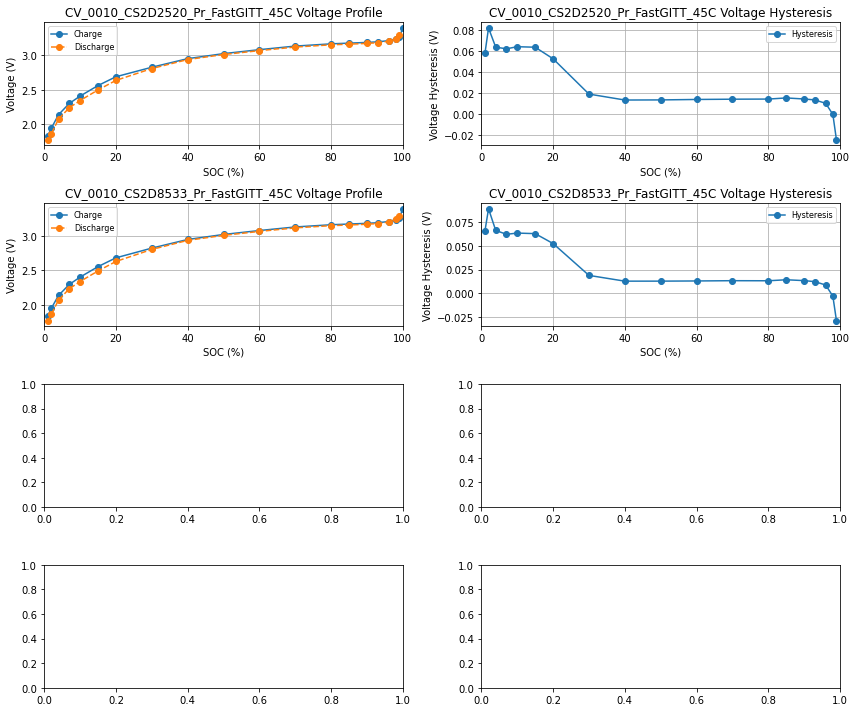

In [9]:
import matplotlib.pyplot as plt

NOMINAL_CAPACITY_AH = 170

if df_hysteresis.empty:
    print("⚠️ No data to plot.")

else:

    test_names = df_hysteresis["test_name"].unique()
    fig, axes = plt.subplots(4, 2, figsize=(12, 10))

    for i, test_name in enumerate(test_names):

        df_test = df_hysteresis[df_hysteresis["test_name"] == test_name].sort_values("soc_percent")

        # Full charge sweep (all SOC points)
        df_charge_all = df_test.dropna(subset=["v_charge_V"])

        # Only points where discharge data also exists
        df_overlap = df_test[df_test["in_both"] == True].sort_values("soc_percent")

        # ----- Left panel: Voltage Profiles -----
        ax_left = axes[i, 0]

        ax_left.plot(
            df_charge_all["soc_percent"],
            df_charge_all["v_charge_V"],
            marker='o',
            linestyle='-',
            label="Charge"
        )
        ax_left.plot(
            df_overlap["soc_percent"],
            df_overlap["v_discharge_V"],
            marker='o',
            linestyle='--',
            label="Discharge"
        )

        ax_left.set_xlabel("SOC (%)")
        ax_left.set_ylabel("Voltage (V)")
        ax_left.set_title(f"{test_name} Voltage Profile")
        ax_left.set_xlim(0, 100)
        ax_left.grid(True)
        ax_left.legend(fontsize=8)

        # ----- Right panel: Voltage Hysteresis -----
        ax_right = axes[i, 1]
        ax_right.plot(
            df_overlap["soc_percent"],
            df_overlap["v_hysteresis_V"],
            marker='o',
            label="Hysteresis"
        )
        ax_right.set_xlabel("SOC (%)")
        ax_right.set_ylabel("Voltage Hysteresis (V)")
        ax_right.set_title(f"{test_name} Voltage Hysteresis")
        ax_right.set_xlim(0, 100)
        ax_right.grid(True)
        ax_right.legend(fontsize=8)

    plt.tight_layout()
    # plt.savefig('FastGITT_CS2D_No100SOC_v1.png', dpi=300)
    plt.show()

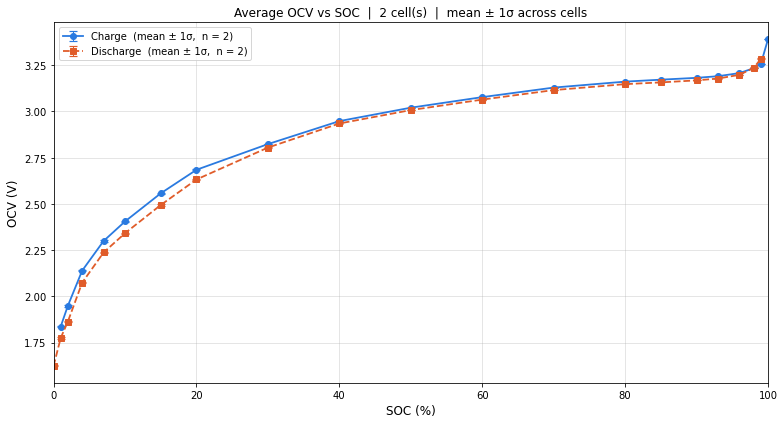

Charge  : 20 SOC steps, 2 cell(s)
Discharge: 20 SOC steps, 2 cell(s)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Average OCV vs SOC — charge & discharge across all loaded cells
# Error bars = 1σ standard deviation across cells at each SOC point
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

if df_hysteresis.empty:
    print("⚠️ No data to plot.")
else:
    n_cells = df_hysteresis["test_name"].nunique()

    # ── Charge: group across all tests at every SOC point ────────────────────
    charge_stats = (
        df_hysteresis
        .dropna(subset=["v_charge_V"])
        .groupby("soc_percent")["v_charge_V"]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
        .sort_values("soc_percent")
    )
    charge_stats["std"] = charge_stats["std"].fillna(0)

    # ── Discharge: only SOC points where discharge data exists ───────────────
    discharge_stats = (
        df_hysteresis
        .dropna(subset=["v_discharge_V"])
        .groupby("soc_percent")["v_discharge_V"]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
        .sort_values("soc_percent")
    )
    discharge_stats["std"] = discharge_stats["std"].fillna(0)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.errorbar(
        charge_stats["soc_percent"],
        charge_stats["mean"],
        yerr=charge_stats["std"],
        label=f"Charge  (mean ± 1σ,  n = {n_cells})",
        color="#2A7AE0",
        linestyle="-",
        marker="o",
        capsize=4,
        capthick=1.2,
        elinewidth=1.0,
        linewidth=1.8,
    )

    ax.errorbar(
        discharge_stats["soc_percent"],
        discharge_stats["mean"],
        yerr=discharge_stats["std"],
        label=f"Discharge  (mean ± 1σ,  n = {n_cells})",
        color="#E05C2A",
        linestyle="--",
        marker="s",
        capsize=4,
        capthick=1.2,
        elinewidth=1.0,
        linewidth=1.8,
    )

    ax.set_xlabel("SOC (%)", fontsize=12)
    ax.set_ylabel("OCV (V)", fontsize=12)
    ax.set_title(
        f"Average OCV vs SOC  |  {n_cells} cell(s)  |  mean ± 1σ across cells",
        fontsize=12,
    )
    ax.set_xlim(0, 100)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig('OCV_Average_AllCells_45C-Claude.png', dpi=300)
    plt.show()

    print(f"Charge  : {len(charge_stats)} SOC steps, {n_cells} cell(s)")
    print(f"Discharge: {len(discharge_stats)} SOC steps, {n_cells} cell(s)")
    if n_cells == 1:
        print("Note: only one cell loaded — error bars are zero (no cell-to-cell spread).")

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CSV Export: averaged OCV vs SOC — charge stacked above discharge
# ─────────────────────────────────────────────────────────────────────────────

# Label and rename each table before stacking
charge_export = charge_stats.copy()
charge_export.insert(0, "Direction", "charge")

discharge_export = discharge_stats.copy()
discharge_export.insert(0, "Direction", "discharge")

ocv_export = pd.concat([charge_export, discharge_export], ignore_index=True)

ocv_export.rename(columns={
    "soc_percent": "SOC_pct",
    "mean":        "OCV_mean_V",
    "std":         "OCV_1sigma_stat_V",
    "count":       "N_cells",
}, inplace=True)

ocv_export = ocv_export[["Direction", "SOC_pct", "OCV_mean_V", "OCV_1sigma_stat_V", "N_cells"]]

output_file = "OCV_Average_AllCells_45C_Round2_final.csv"
ocv_export.to_csv(output_file, index=False)

print(f"Exported → '{output_file}'  ({len(ocv_export)} rows)")
print(f"  Charge rows    : {len(charge_export)}")
print(f"  Discharge rows : {len(discharge_export)}")
print()
print("Column legend:")
print("  OCV_mean_V         : mean OCV across all loaded cells at each SOC point")
print("  OCV_1sigma_stat_V  : 1σ standard deviation across cells")
print("  N_cells            : number of cells contributing to each SOC point")

Exported → 'OCV_Average_AllCells_45C_Round2_final.csv'  (40 rows)
  Charge rows    : 20
  Discharge rows : 20

Column legend:
  OCV_mean_V         : mean OCV across all loaded cells at each SOC point
  OCV_1sigma_stat_V  : 1σ standard deviation across cells
  N_cells            : number of cells contributing to each SOC point


In [29]:
# --- Export GITT Hysteresis Data to CSV UTF-8 ---

import os

# Folder to save CSVs (adjust path as needed)
output_folder = "gitt_hysteresis_csvs_HighRez_25C_Final_v1"
os.makedirs(output_folder, exist_ok=True)

if df_hysteresis.empty:
    print("⚠️ No data to export.")

else:
    test_names = df_hysteresis["test_name"].unique()
    
    for test_name in test_names:
        # Extract data for this test
        df_test = df_hysteresis[df_hysteresis["test_name"] == test_name].sort_values("soc_percent")

        # Optionally, add absolute capacity column
        df_test = df_test.copy()
        NOMINAL_CAPACITY_AH = 170
        df_test["capacity_ah"] = df_test["soc_percent"] / 100 * NOMINAL_CAPACITY_AH

        # Create a safe filename
        safe_name = "".join(c if c.isalnum() or c in "_-" else "_" for c in test_name)
        csv_path = os.path.join(output_folder, f"{safe_name}.csv")

        # Export CSV UTF-8
        df_test.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"✅ Exported {csv_path}")

✅ Exported gitt_hysteresis_csvs_HighRez_25C_v1/CV_0010_CS2D9388_Pr_FastGITT_25C.csv
✅ Exported gitt_hysteresis_csvs_HighRez_25C_v1/CV_0010_CS2D8795_Pr_FastGITT_25C.csv
✅ Exported gitt_hysteresis_csvs_HighRez_25C_v1/CV_0010_CS2D8770_Pr_FastGITT_25C.csv
✅ Exported gitt_hysteresis_csvs_HighRez_25C_v1/CV_0010_CS2D9392_Pr_FastGITT_25C.csv
